# Exploratory Data Analysis — price prediction
**Objectif** : EDA.

**Dataset** : `immobilier_dataset.csv`  
**Auteur** : Romaric TCHOFFO  
**Date** : 2026

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df =  pd.read_csv('../data/raw_data/immo_dataset_messy.csv')
df.head()

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,...,Fireplaces,LotArea,Neighborhood,ExterQual,PropertyType,DPE,HasPool,AgentID,SaleDate,SalePrice
0,4,157.8,92.9,882.31,1931.0,2018.0,1,570.38,1.0,2,...,0,314.9,Belleville,TA,Loft,NaN,0,NaN,2015-02-02,807342.0
1,6,117.1,101.0,720.4,1932.0,1974.0,1,537.17,1.0,4,...,1,305.3,Oberkampf,Gd,Studio,F,0,NaN,3/10/2022,694289.0
2,6,222.2,50.1,493.71,1921.0,1913.0,0,503.67,1.0,2,...,1,416.6,Clignancourt,gd,Appartement,NaN,0,NaN,2022-04-13,1548894.0
3,6,221.7,5.2,1096.16,1929.0,1904.0,2,426.36,1.0,7,...,3,906.6,Bastille,Gd,Appartement,NaN,0,NaN,NaN,1200124.0
4,5,140.9,83.9,1411.8,1967.0,1900.0,Oui,794.74,3.0,5,...,1,875.2,Auteuil,Fa,Appartement,E,0,NaN,2016-04-12,1005079.0


In [3]:
df.columns.tolist()

['OverallQual',
 'GrLivArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'YearBuilt',
 'YearRemodAdd',
 'GarageCars',
 'GarageArea',
 'FullBath',
 'TotRmsAbvGrd',
 'KitchenQual',
 'Fireplaces',
 'LotArea',
 'Neighborhood',
 'ExterQual',
 'PropertyType',
 'DPE',
 'HasPool',
 'AgentID',
 'SaleDate',
 'SalePrice']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   8220 non-null   object 
 1   GrLivArea     8229 non-null   object 
 2   TotalBsmtSF   7965 non-null   float64
 3   1stFlrSF      8238 non-null   object 
 4   YearBuilt     8226 non-null   float64
 5   YearRemodAdd  8225 non-null   float64
 6   GarageCars    8182 non-null   object 
 7   GarageArea    8054 non-null   object 
 8   FullBath      8151 non-null   float64
 9   TotRmsAbvGrd  8169 non-null   object 
 10  KitchenQual   8017 non-null   object 
 11  Fireplaces    8159 non-null   object 
 12  LotArea       8033 non-null   object 
 13  Neighborhood  8208 non-null   object 
 14  ExterQual     7969 non-null   object 
 15  PropertyType  8257 non-null   object 
 16  DPE           5706 non-null   object 
 17  HasPool       8164 non-null   object 
 18  AgentID       4813 non-null 

In [5]:
df.dtypes.value_counts()

object     16
float64     5
Name: count, dtype: int64

In [6]:
df.describe()

,TotalBsmtSF,YearBuilt,YearRemodAdd,FullBath,SalePrice
count,7965.000000,8226.000000,8225.000000,8151.00000,8.254000e+03
mean,81.452015,1939.587284,1942.282675,1.86333,2.165584e+06
std,54.319229,202.561306,197.871635,1.20570,3.794915e+07
min,-50.000000,0.000000,0.000000,0.00000,0.000000e+00
25%,39.100000,1928.000000,1930.000000,1.00000,4.835730e+05
50%,78.000000,1961.000000,1962.000000,2.00000,7.782060e+05
75%,118.800000,1993.000000,1994.000000,2.00000,1.158086e+06
max,300.000000,2099.000000,2099.000000,10.00000,3.364371e+09


In [7]:
((df.isna().sum().sort_values(ascending=False).to_frame(name='missing_values')*100)/len(df)).round(2)

,missing_values
AgentID,42.70
DPE,32.07
TotalBsmtSF,5.18
ExterQual,5.13
KitchenQual,4.56
LotArea,4.37
GarageArea,4.12
FullBath,2.96
Fireplaces,2.87
HasPool,2.81


In [8]:
df['SalePrice'].describe()

count    8.254000e+03
mean     2.165584e+06
std      3.794915e+07
min      0.000000e+00
25%      4.835730e+05
50%      7.782060e+05
75%      1.158086e+06
max      3.364371e+09
Name: SalePrice, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(121)

In [10]:
df.dtypes.to_frame("Type").T

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,...,Fireplaces,LotArea,Neighborhood,ExterQual,PropertyType,DPE,HasPool,AgentID,SaleDate,SalePrice
Type,object,object,float64,object,float64,float64,object,object,float64,object,...,object,object,object,object,object,object,object,object,object,float64


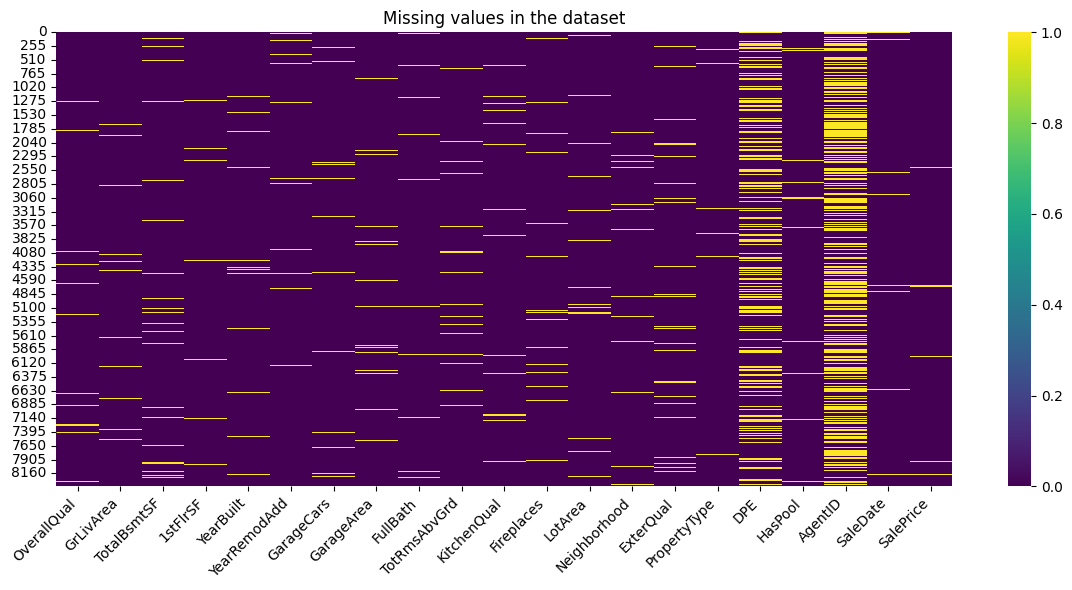

In [11]:
missing = df.isna()
plt.figure(figsize=(12, 6))
sns.heatmap(missing, annot=False, cmap='viridis')
plt.title("Missing values in the dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
df.head(2)

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,...,Fireplaces,LotArea,Neighborhood,ExterQual,PropertyType,DPE,HasPool,AgentID,SaleDate,SalePrice
0,4,157.8,92.9,882.31,1931.0,2018.0,1,570.38,1.0,2,...,0,314.9,Belleville,TA,Loft,NaN,0,NaN,2015-02-02,807342.0
1,6,117.1,101.0,720.4,1932.0,1974.0,1,537.17,1.0,4,...,1,305.3,Oberkampf,Gd,Studio,F,0,NaN,3/10/2022,694289.0


In [13]:
variables_discrete = ['OverallQual','YearBuilt','YearRemodAdd','GarageCars','FullBath','TotRmsAbvGrd','Fireplaces','LotArea','Neighborhood','PropertyType','SaleDate']
variables_continues =['GrLivArea','TotalBsmtSF','1stFlrSF','GarageArea']
variables_categoriel =['KitchenQual','ExterQual','DPE']
variables_discrete_binary = ['HasPool']
variables_cible=['SalePrice']

OverallQual
6       1986
5       1902
7       1302
4       1242
3        574
8        545
9        158
2        123
15        95
-1        86
0         81
1         27
6/10      26
10        19
7/10      17
5/10      11
4/10      10
2/10       6
3/10       6
8/10       4
Name: count, dtype: int64


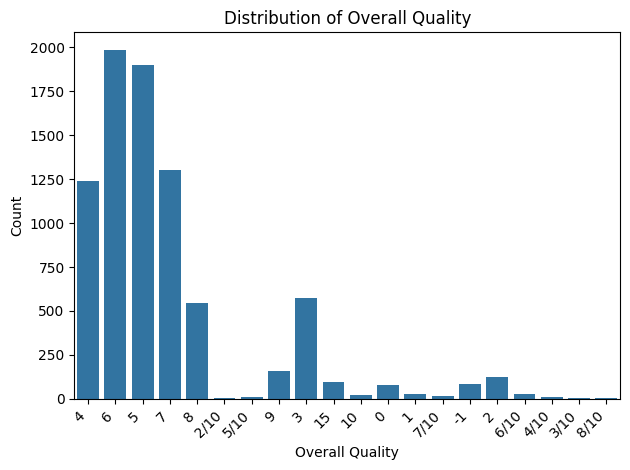

In [14]:
print(df['OverallQual'].value_counts())

sns.countplot(x='OverallQual', data=df)
plt.title('Distribution of Overall Quality')
plt.xlabel('Overall Quality')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.ylabel('Count')
plt.show()


In [15]:
df['GrLivArea'].describe()

count     8229
unique    2462
top         10
freq       123
Name: GrLivArea, dtype: object

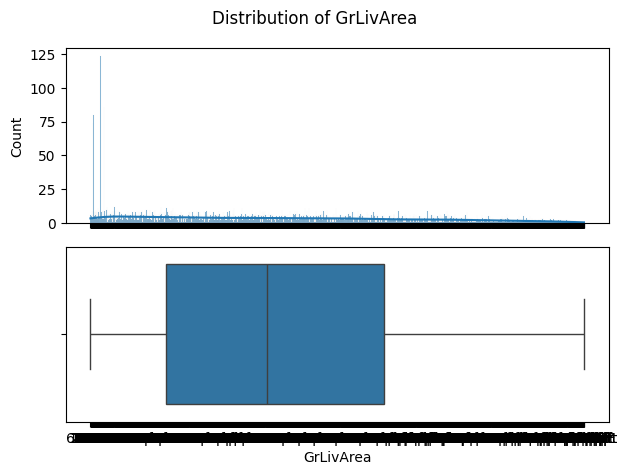

In [16]:
fig,ax = plt.subplots(2,1, sharex=True)
plt.suptitle('Distribution of GrLivArea')
sns.histplot(df['GrLivArea'], bins=30, kde=True, ax=ax[0])
sns.boxplot(x=df['GrLivArea'], ax=ax[1])
plt.tight_layout()
plt.show()

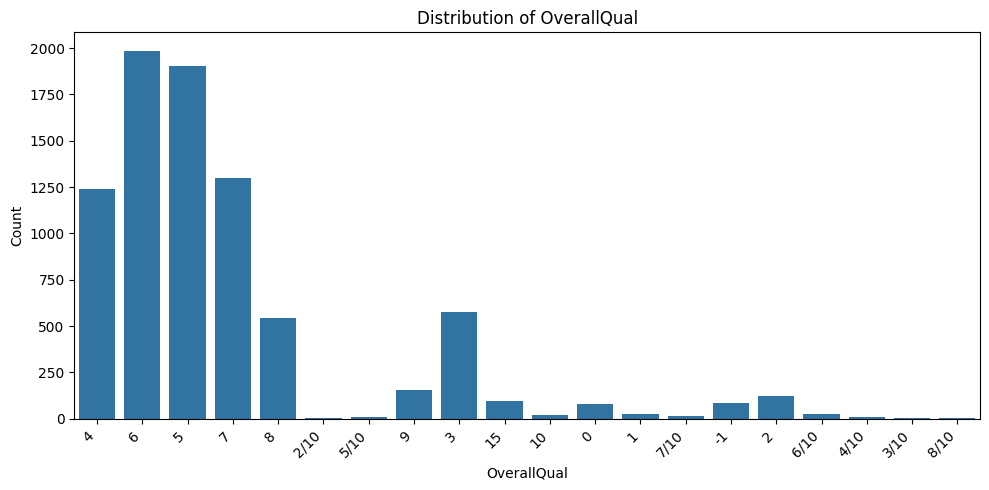

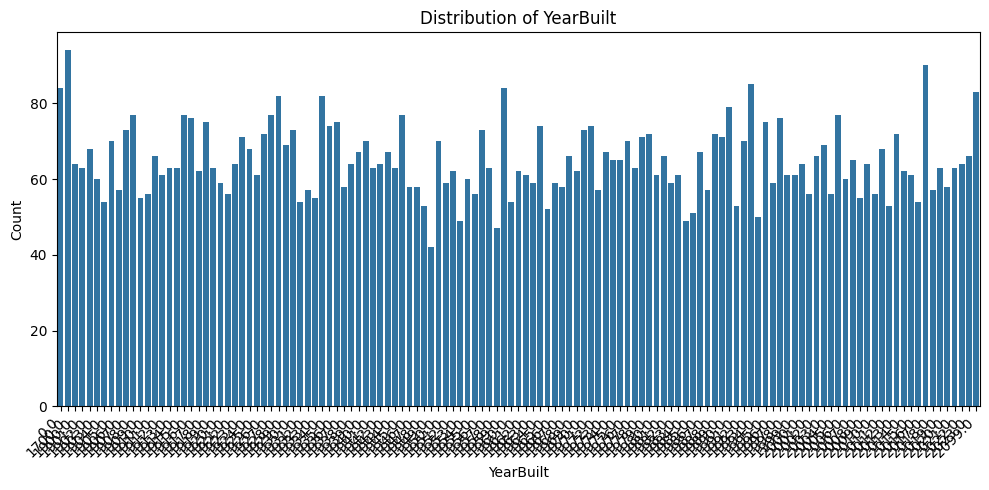

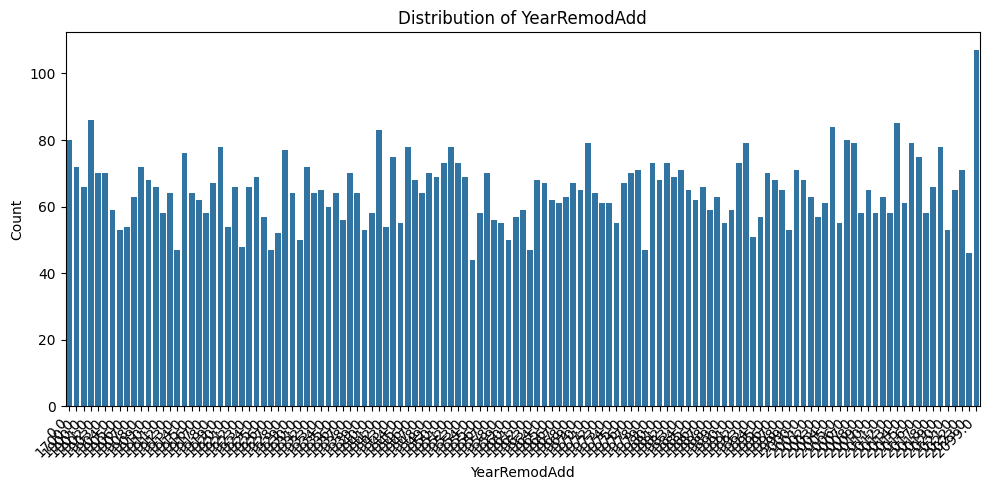

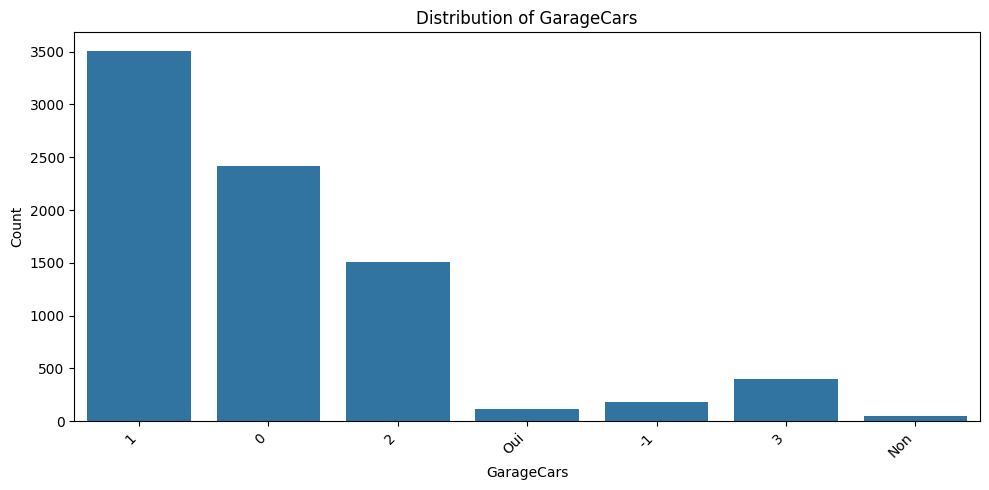

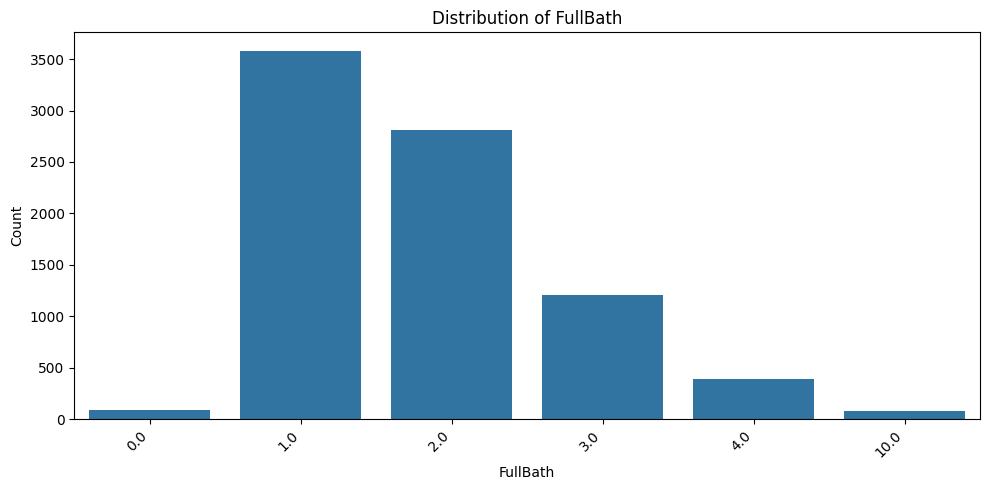

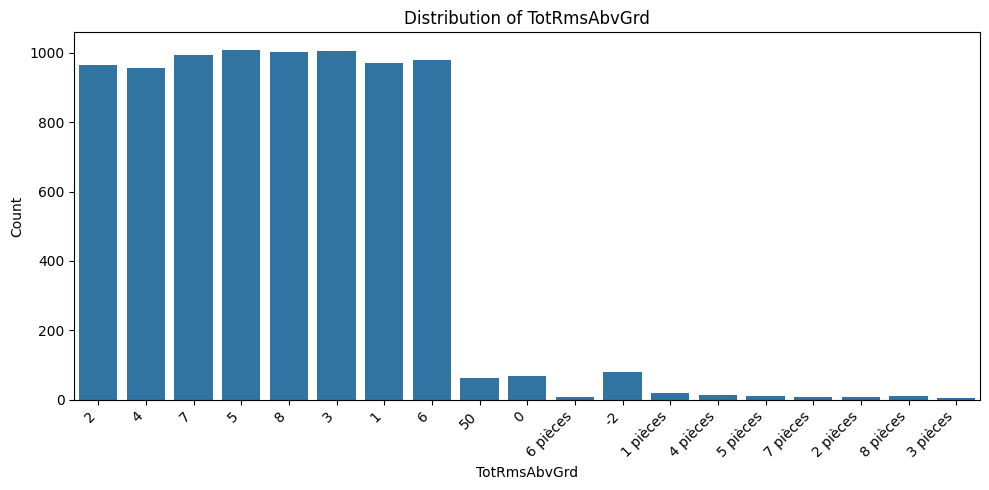

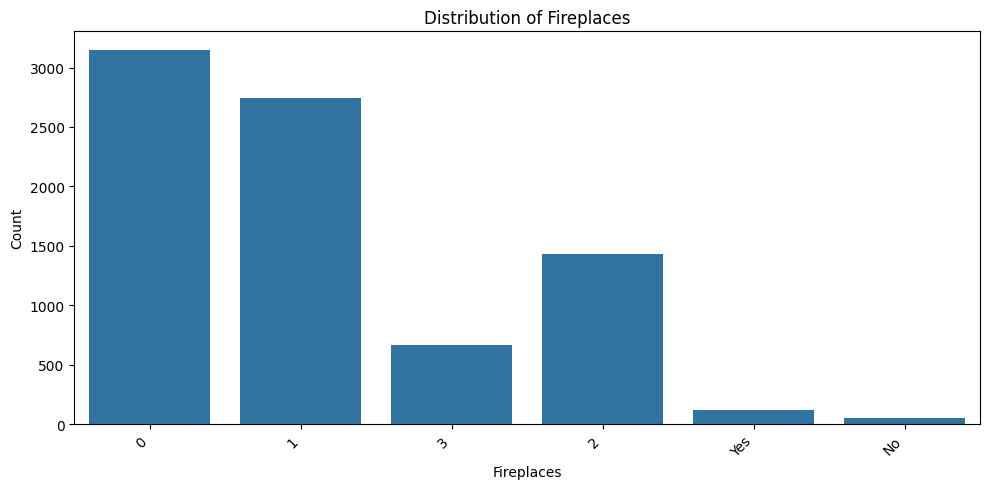

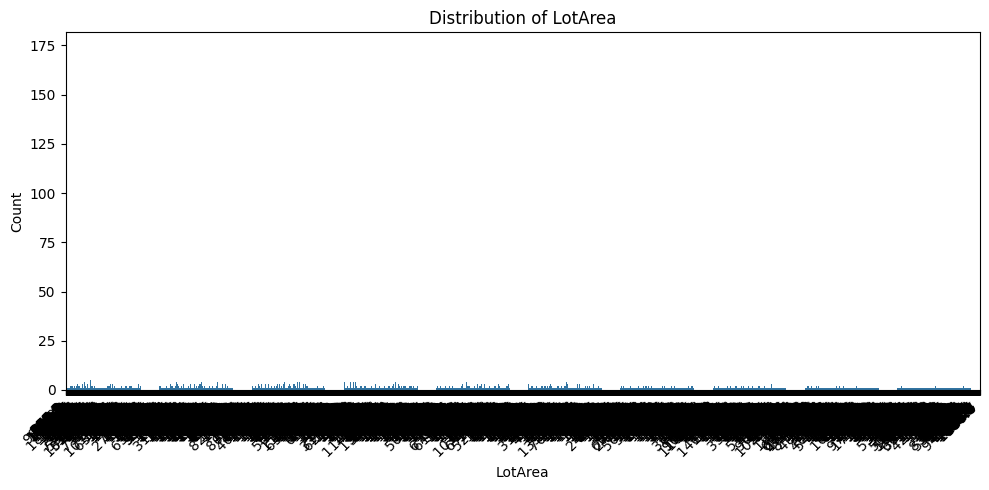

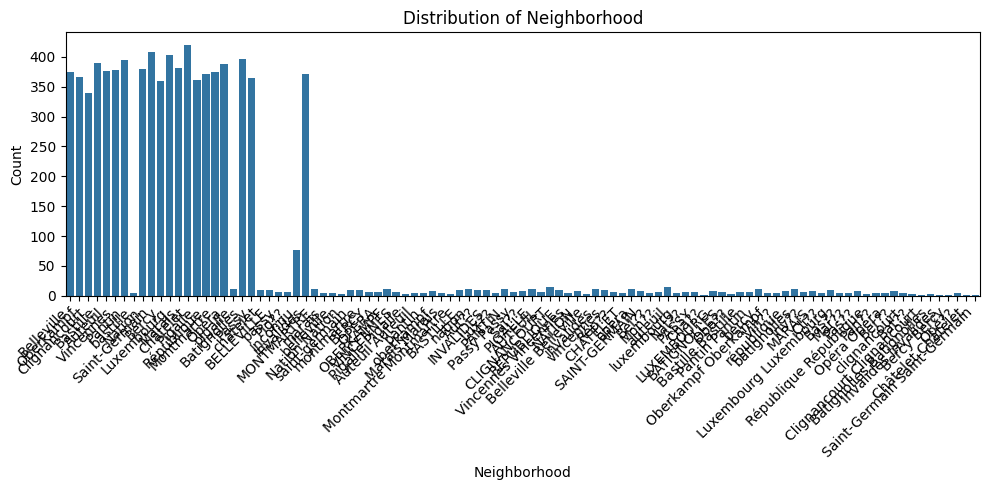

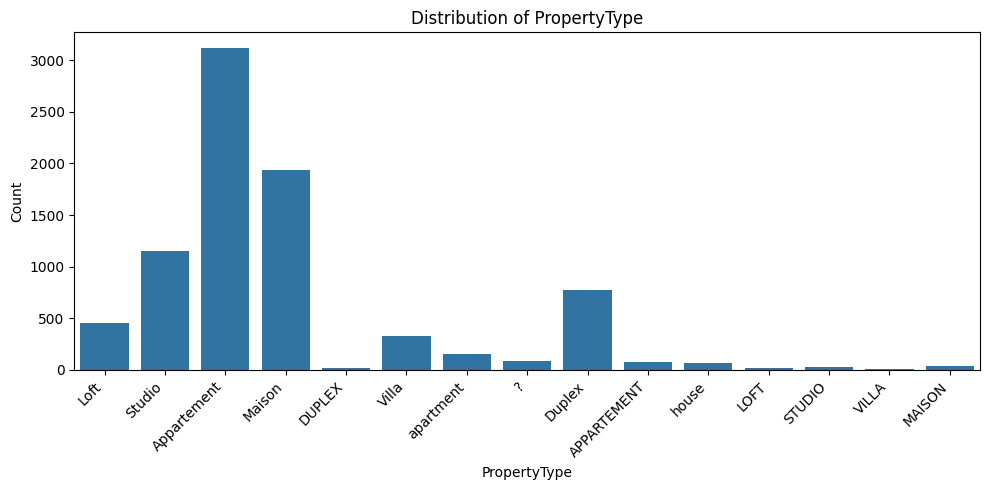

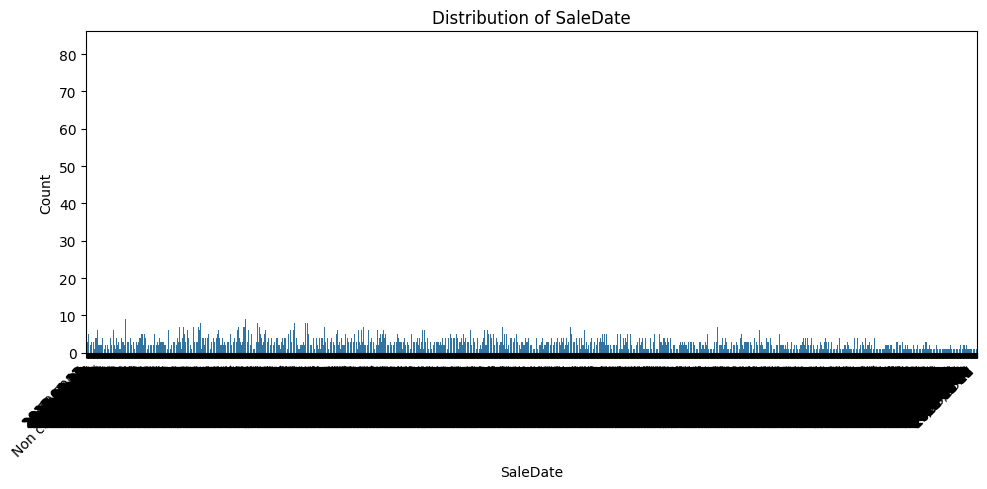

In [17]:
variables_discrete = ['OverallQual','YearBuilt','YearRemodAdd','GarageCars','FullBath','TotRmsAbvGrd','Fireplaces','LotArea','Neighborhood','PropertyType','SaleDate']
for i in variables_discrete:
    plt.figure(figsize=(10,5))
    sns.countplot(x=i, data=df)
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.ylabel('Count')
    plt.show()

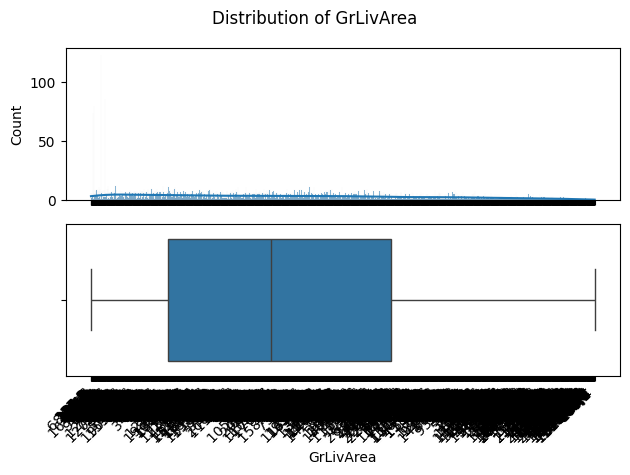

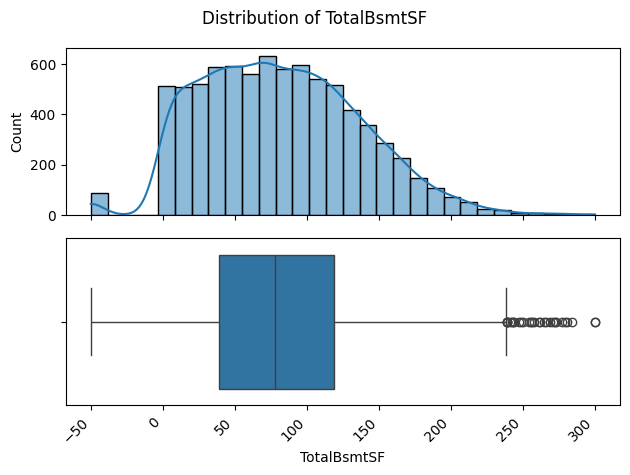

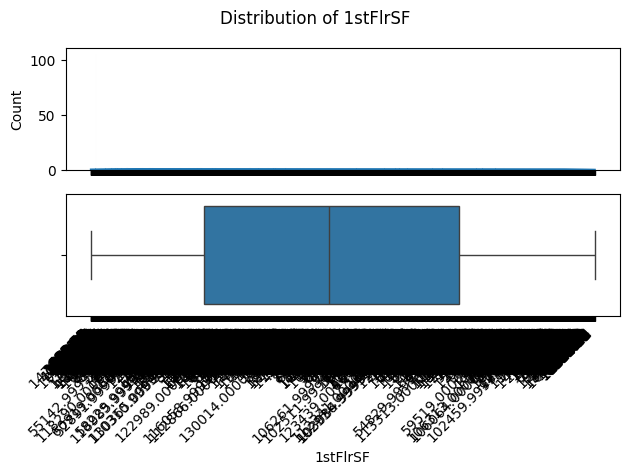

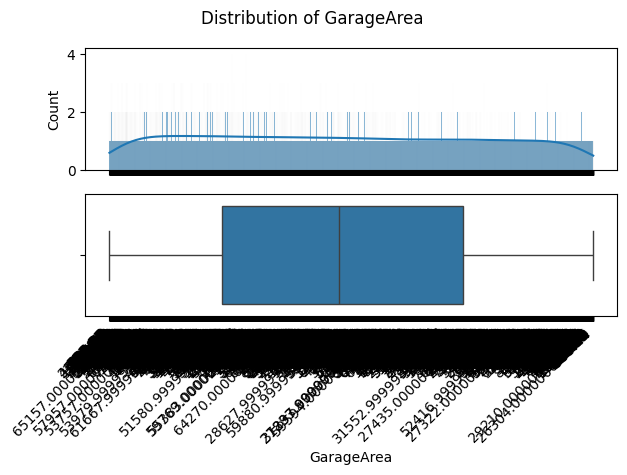

In [18]:
variables_continues =['GrLivArea','TotalBsmtSF','1stFlrSF','GarageArea']

for i in variables_continues:
    fig,ax = plt.subplots(2,1, sharex=True)
    plt.suptitle(f'Distribution of {i}')
    sns.histplot(df[i],bins=30,kde=True,ax=ax[0])
    sns.boxplot(x=df[i],ax=ax[1])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

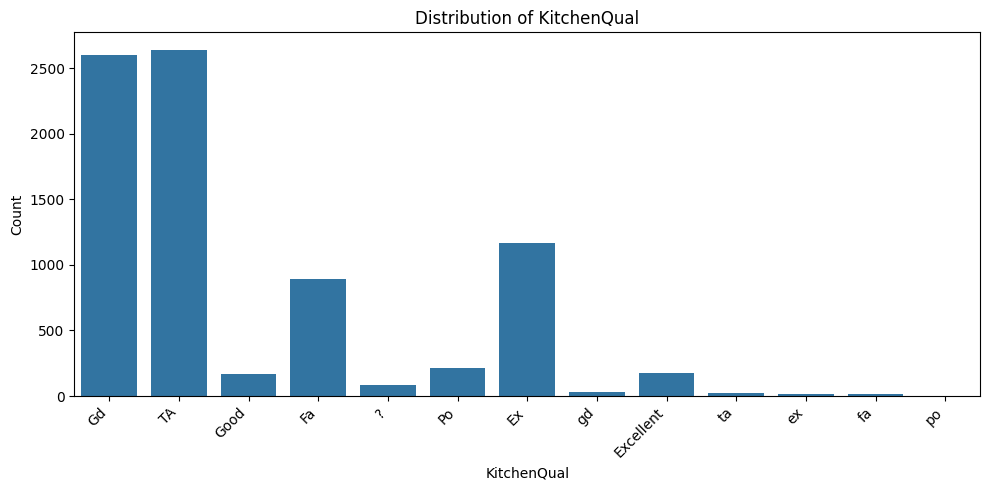

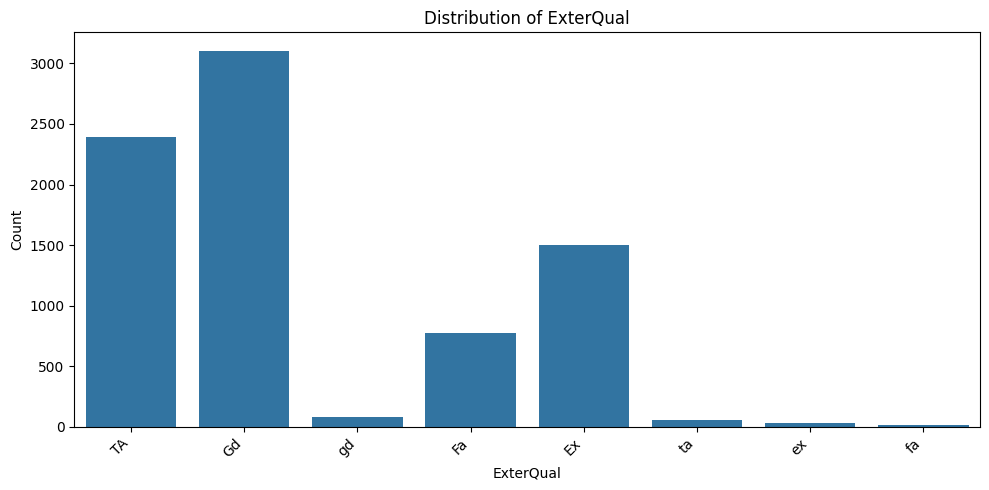

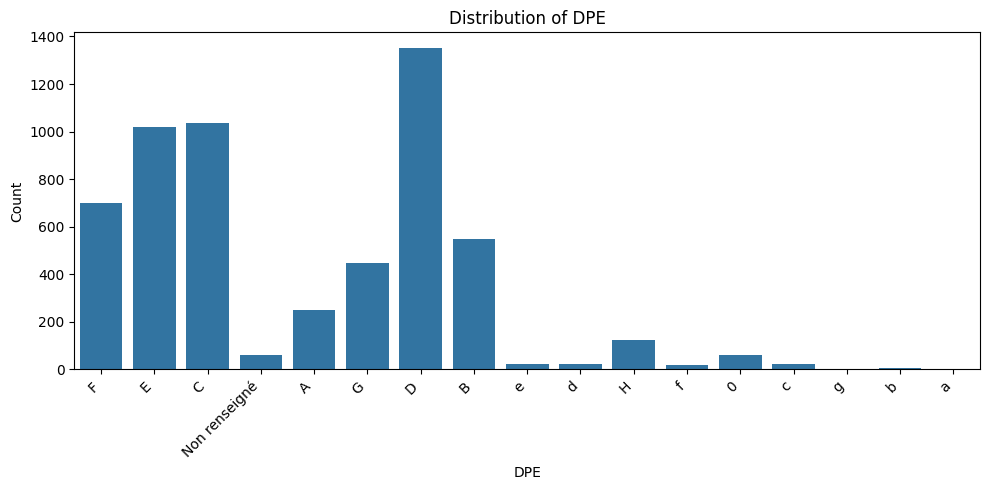

In [19]:
variables_categoriel =['KitchenQual','ExterQual',"DPE"]

for i in variables_categoriel:
    plt.figure(figsize=(10,5))
    plt.title(f'Distribution of {i}')
    sns.countplot(x=i, data=df)
    plt.xlabel(i)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.ylabel('Count')
    plt.show()

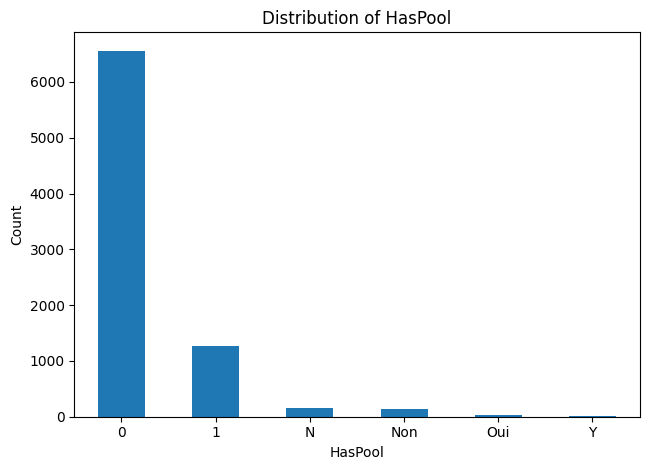

In [20]:
variables_discrete_binary = ['HasPool']
df['HasPool'].value_counts().plot(kind='bar')
plt.title('Distribution of HasPool')
plt.xlabel('HasPool')      
plt.xticks(rotation=0)
plt.tight_layout()
plt.ylabel('Count')
plt.show()

In [21]:
df['SalePrice'].describe()

count    8.254000e+03
mean     2.165584e+06
std      3.794915e+07
min      0.000000e+00
25%      4.835730e+05
50%      7.782060e+05
75%      1.158086e+06
max      3.364371e+09
Name: SalePrice, dtype: float64

Text(0.5, 1.0, 'Distribution of SalePrice')

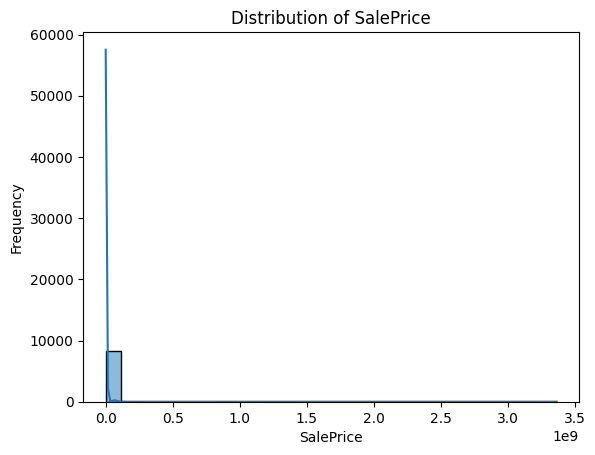

In [22]:
df['SalePrice'].describe().plot(kind='hist')
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('Distribution of SalePrice')  



## 9. Analyse de la Correlation entre les variables


In [23]:
df.dtypes.to_frame("Type").T

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,...,Fireplaces,LotArea,Neighborhood,ExterQual,PropertyType,DPE,HasPool,AgentID,SaleDate,SalePrice
Type,object,object,float64,object,float64,float64,object,object,float64,object,...,object,object,object,object,object,object,object,object,object,float64


In [24]:
# Ne convertir que les colonnes vraiment numériques
cols_numeriques = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF',
                   'YearBuilt', 'YearRemodAdd', 'GarageCars', 'GarageArea',
                   'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
                   'HasPool', 'SalePrice']


# Conversion correcte par type
df_corr = df[cols_numeriques].apply(pd.to_numeric, errors='coerce')
df_corr.dtypes.to_frame("Type").T


,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,Fireplaces,LotArea,HasPool,SalePrice
Type,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


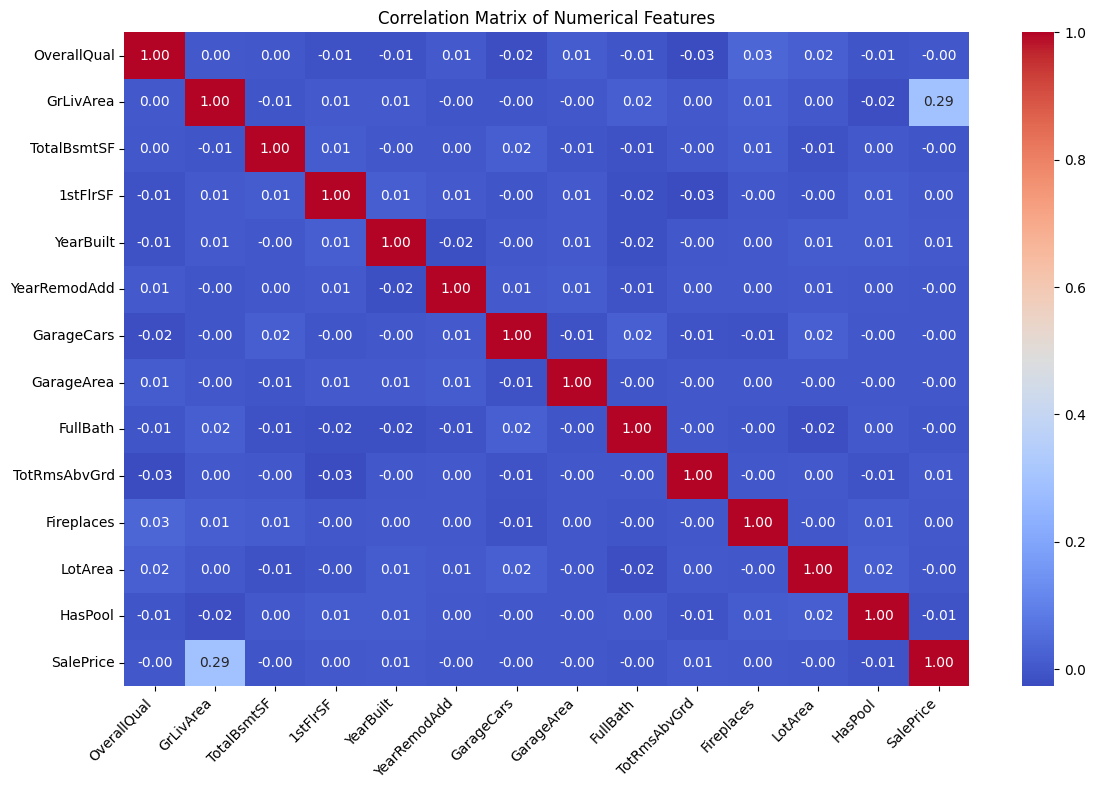

In [25]:
corr = df_corr.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [26]:

q1 = df_corr['GrLivArea'].quantile(0.25)
q3 = df_corr['GrLivArea'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")


Lower bound: -49.45000000000003, Upper bound: 288.55000000000007


In [27]:
q1 = df_corr['TotalBsmtSF'].quantile(0.25)
q3 = df_corr['TotalBsmtSF'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr    
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -80.44999999999999, Upper bound: 238.34999999999997


In [28]:
q1 = df_corr['1stFlrSF'].quantile(0.25)
q3 = df_corr['1stFlrSF'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")



Lower bound: 98.70500000000015, Upper bound: 1807.6049999999998


In [29]:
q1 = df_corr['GarageArea'].quantile(0.25)
q3 = df_corr['GarageArea'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -116.10750000000002, Upper bound: 1018.8725
